In [ ]:
# ============================================================================
# Full Experimental Suite for New Re Indicator Research (UI & Logic Fix)
# ============================================================================

# 1. Install and import dependencies
!pip uninstall torchvision torchaudio -y
!pip install -U datasets huggingface_hub transformers accelerate -q

import os
os.environ["DATASETS_USE_TORCHVISION"] = "0"
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
    get_linear_schedule_with_warmup, default_data_collator
)
from datasets import load_dataset
from tqdm.notebook import tqdm  # Use notebook-specific tqdm to prevent multi-line UI issues
from collections import deque
import warnings
import gc
import math
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 2. Configure global seed and device
# ------------------------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ------------------------------------------------------------
# 3. Load model, tokenizer, and datasets
# ------------------------------------------------------------
model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# Clear cache to avoid dataset corruption
!rm -rf ~/.cache/huggingface/datasets/wikitext

dataset_train = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
dataset_valid = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="validation")

def tokenize(examples):
    return tokenizer(
        examples["text"], truncation=True, max_length=256,
        padding="max_length", return_tensors="pt"
    )

train_data = dataset_train.map(tokenize, batched=True, remove_columns=["text"])
valid_data = dataset_valid.map(tokenize, batched=True, remove_columns=["text"])
train_data.set_format("torch", columns=["input_ids", "attention_mask"])
valid_data.set_format("torch", columns=["input_ids", "attention_mask"])

BATCH_SIZE = 4
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=default_data_collator)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=default_data_collator)

# ------------------------------------------------------------
# 4. Core physics capture helper functions
# ------------------------------------------------------------
def get_flat_params(model):
    """Flatten all model parameters into a 1D CPU tensor."""
    with torch.no_grad():
        return torch.cat([p.data.view(-1) for p in model.parameters()]).cpu()

def evaluate_loss(model, data_loader):
    """Evaluate the model on a subset of the validation set for speed."""
    model.eval()
    total_loss = 0.0
    total_batches = 0
    with torch.no_grad():
        for batch in data_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch, labels=batch["input_ids"])
            total_loss += outputs.loss.item()
            total_batches += 1
            if total_batches > 50: break
    model.train()
    return total_loss / total_batches

# ------------------------------------------------------------
# 5. Main training loop with physics recording
# ------------------------------------------------------------
def train_and_monitor_physics(optimizer_type="adam", learning_rate=5e-4,
                               total_steps=20000, record_interval=20):
    """
    Train GPT-2 and record both validation loss and physical quantities
    (v, a, Re_old, Re_new, m, gamma) for post-hoc analysis.
    """
    # Initialize a fresh model for independent runs
    model = GPT2LMHeadModel.from_pretrained(model_name).to(device)

    # Setup Optimizer
    if optimizer_type == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999))
        warmup_steps = 100
        beta1 = 0.9
        momentum_beta = None
    else: # SGD-Momentum
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
        warmup_steps = 50
        beta1 = None
        momentum_beta = 0.9

    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )

    # Data storage
    param_queue = deque(maxlen=3)
    steps = []
    v_norm_list, a_norm_list = [], []
    Re_old_raw_list, Re_old_ema_list = [], []
    Re_new_raw_list, Re_new_ema_list = [], []
    train_losses, val_losses, val_step_markers = [], [], []
    mass_history, gamma_history = [], []

    step = 0
    # Use notebook tqdm to prevent line-breaking in Colab output
    pbar = tqdm(total=total_steps, desc=f"Training {optimizer_type.upper()}", position=0, leave=True)

    ema_alpha = 0.9
    ema_re_old = None
    ema_re_new = None

    while step < total_steps:
        for batch in train_loader:
            if step >= total_steps: break

            # --- 1. Standard training step ---
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch, labels=batch["input_ids"])
            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            train_losses.append(loss.item())

            # --- 2. Periodic physics sampling (sparse to save IO) ---
            if step % record_interval == 0:
                flat = get_flat_params(model)
                param_queue.append(flat)
                steps.append(step)

                if len(param_queue) >= 3:
                    v_k = param_queue[1] - param_queue[0]
                    v_k1 = param_queue[2] - param_queue[1]
                    a_k = v_k1 - v_k

                    norm_v = torch.norm(v_k).item()
                    norm_a = torch.norm(a_k).item()

                    # 1. Calculate Old Re = ||a_k|| / ||v_k||
                    re_old = norm_a / (norm_v + 1e-12)

                    # 2. Calculate New Re = (m_k * ||a_k||) / (gamma_k * ||v_k||)
                    # First, retrieve physical mass and damping
                    if optimizer_type == "adam":
                        # Adam: Compute m_k and gamma_k dynamically
                        total_exp_avg_sq = 0.0
                        count = 0
                        for group in optimizer.param_groups:
                            for p in group['params']:
                                state = optimizer.state[p]
                                if 'exp_avg_sq' in state:
                                    total_exp_avg_sq += torch.mean(state['exp_avg_sq']).item()
                                    count += 1

                        if count > 0:
                            avg_sq = total_exp_avg_sq / count
                            eps = 1e-8
                            # Eq. 49: effective learning rate
                            eta_eff = optimizer.param_groups[0]['lr'] / (math.sqrt(avg_sq) + eps)
                            # Eq. 48: current mass m_{k+1}
                            mass_current = 1.0 / (eta_eff * (1 - beta1))

                            if len(mass_history) > 0:
                                previous_mass = mass_history[-1]
                                # gamma_k = m_k - beta1 * m_{k+1}
                                gamma_current = previous_mass - beta1 * mass_current
                            else:
                                gamma_current = 0.0

                            mass_history.append(mass_current)
                            gamma_history.append(gamma_current)
                        mass = mass_current
                        gamma = gamma_current
                    else:
                        # SGD-Momentum: Constant mass and damping (Eq. 35)
                        mass = 1.0 / learning_rate
                        gamma = (1 - momentum_beta) / learning_rate
                        mass_history.append(mass)
                        gamma_history.append(gamma)

                    # Compute New Re
                    re_new = (mass * norm_a) / (gamma * norm_v + 1e-12)

                    # Store physical kinematics
                    v_norm_list.append(norm_v)
                    a_norm_list.append(norm_a)

                    # Store Old Re
                    Re_old_raw_list.append(re_old)
                    if ema_re_old is None:
                        ema_re_old = re_old
                    else:
                        ema_re_old = ema_alpha * ema_re_old + (1 - ema_alpha) * re_old
                    Re_old_ema_list.append(ema_re_old)

                    # Store New Re
                    Re_new_raw_list.append(re_new)
                    if ema_re_new is None:
                        ema_re_new = re_new
                    else:
                        ema_re_new = ema_alpha * ema_re_new + (1 - ema_alpha) * re_new
                    Re_new_ema_list.append(ema_re_new)

                    # Update the progress bar description ONLY during sampling
                    # This prevents the UI from spamming new lines
                    pbar.set_description(
                        f"{optimizer_type.upper()} | Loss: {loss.item():.3f} | Re_old: {ema_re_old:.3e}"
                    )

            # --- 3. Validation evaluation ---
            if step % 500 == 0 and step > 0:
                val_loss = evaluate_loss(model, valid_loader)
                val_losses.append(val_loss)
                val_step_markers.append(step)

            # --- 4. UI Update ---
            step += 1
            pbar.update(1)

    pbar.close()

    # Free memory
    del model
    torch.cuda.empty_cache()
    gc.collect()

    return {
        "steps": steps,
        "Re_old_raw": Re_old_raw_list,
        "Re_old_ema": Re_old_ema_list,
        "Re_new_raw": Re_new_raw_list,
        "Re_new_ema": Re_new_ema_list,
        "v_norm": v_norm_list,
        "a_norm": a_norm_list,
        "mass_history": mass_history,
        "gamma_history": gamma_history,
        "train_loss": train_losses,
        "val_loss": val_losses,
        "val_steps": val_step_markers
    }

# ============================================================================
# 6. Batch experiment controller (scans different LRs)
# ============================================================================
# Because previous runs showed Adam overfits at ~18k, SGD at ~24.5k,
# we allocate 20k steps for Adam and 26k steps for SGD to capture the rebound.
experiments = [
    {"name": "sgd_1e-3",   "opt": "sgd", "lr": 1e-3},
    {"name": "sgd_3e-3",   "opt": "sgd", "lr": 3e-3},
    {"name": "sgd_5e-3",   "opt": "sgd", "lr": 5e-3},
    {"name": "sgd_7e-3",   "opt": "sgd", "lr": 7e-3},
    {"name": "sgd_1e-2",   "opt": "sgd", "lr": 1e-2},
    {"name": "adam_5e-4",  "opt": "adam", "lr": 5e-4}
]

for exp in experiments:
    current_steps = 20000 if exp["opt"] == "adam" else 26000

    print(f"\n{'='*50}")
    print(f"Running: {exp['name']} | {exp['opt'].upper()} | LR: {exp['lr']} | Steps: {current_steps}")
    print(f"{'='*50}")

    exp_data = train_and_monitor_physics(
        optimizer_type=exp["opt"],
        learning_rate=exp["lr"],
        total_steps=current_steps,
        record_interval=20
    )

    # Save individual experiment files for the paper's multi-LR analysis
    np.savez(f"re_data_{exp['name']}.npz", **exp_data)
    print(f"✅ Data saved to re_data_{exp['name']}.npz")

Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 149.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 54.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timm 1.0.28 requires torchvision, which is not installed.
Device: cuda


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Training SGD:   0%|          | 0/26000 [00:00<?, ?it/s]

✅ Data saved to re_data_sgd_1e-2.npz

Running: adam_5e-4 | ADAM | LR: 0.0005 | Steps: 20000


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Training ADAM:   0%|          | 0/20000 [00:00<?, ?it/s]

✅ Data saved to re_data_adam_5e-4.npz


In [ ]:
!unzip all_experiments_results.zip

Archive:  all_experiments_results.zip
 extracting: re_data_sgd_1e-3.npz    
 extracting: re_data_sgd_7e-3.npz    
 extracting: re_data_sgd_5e-3.npz    
 extracting: re_data_sgd_3e-3.npz    
 extracting: re_data_sgd_1e-2.npz    
 extracting: re_data_adam_5e-4.npz   


Found 6 experiment data files.


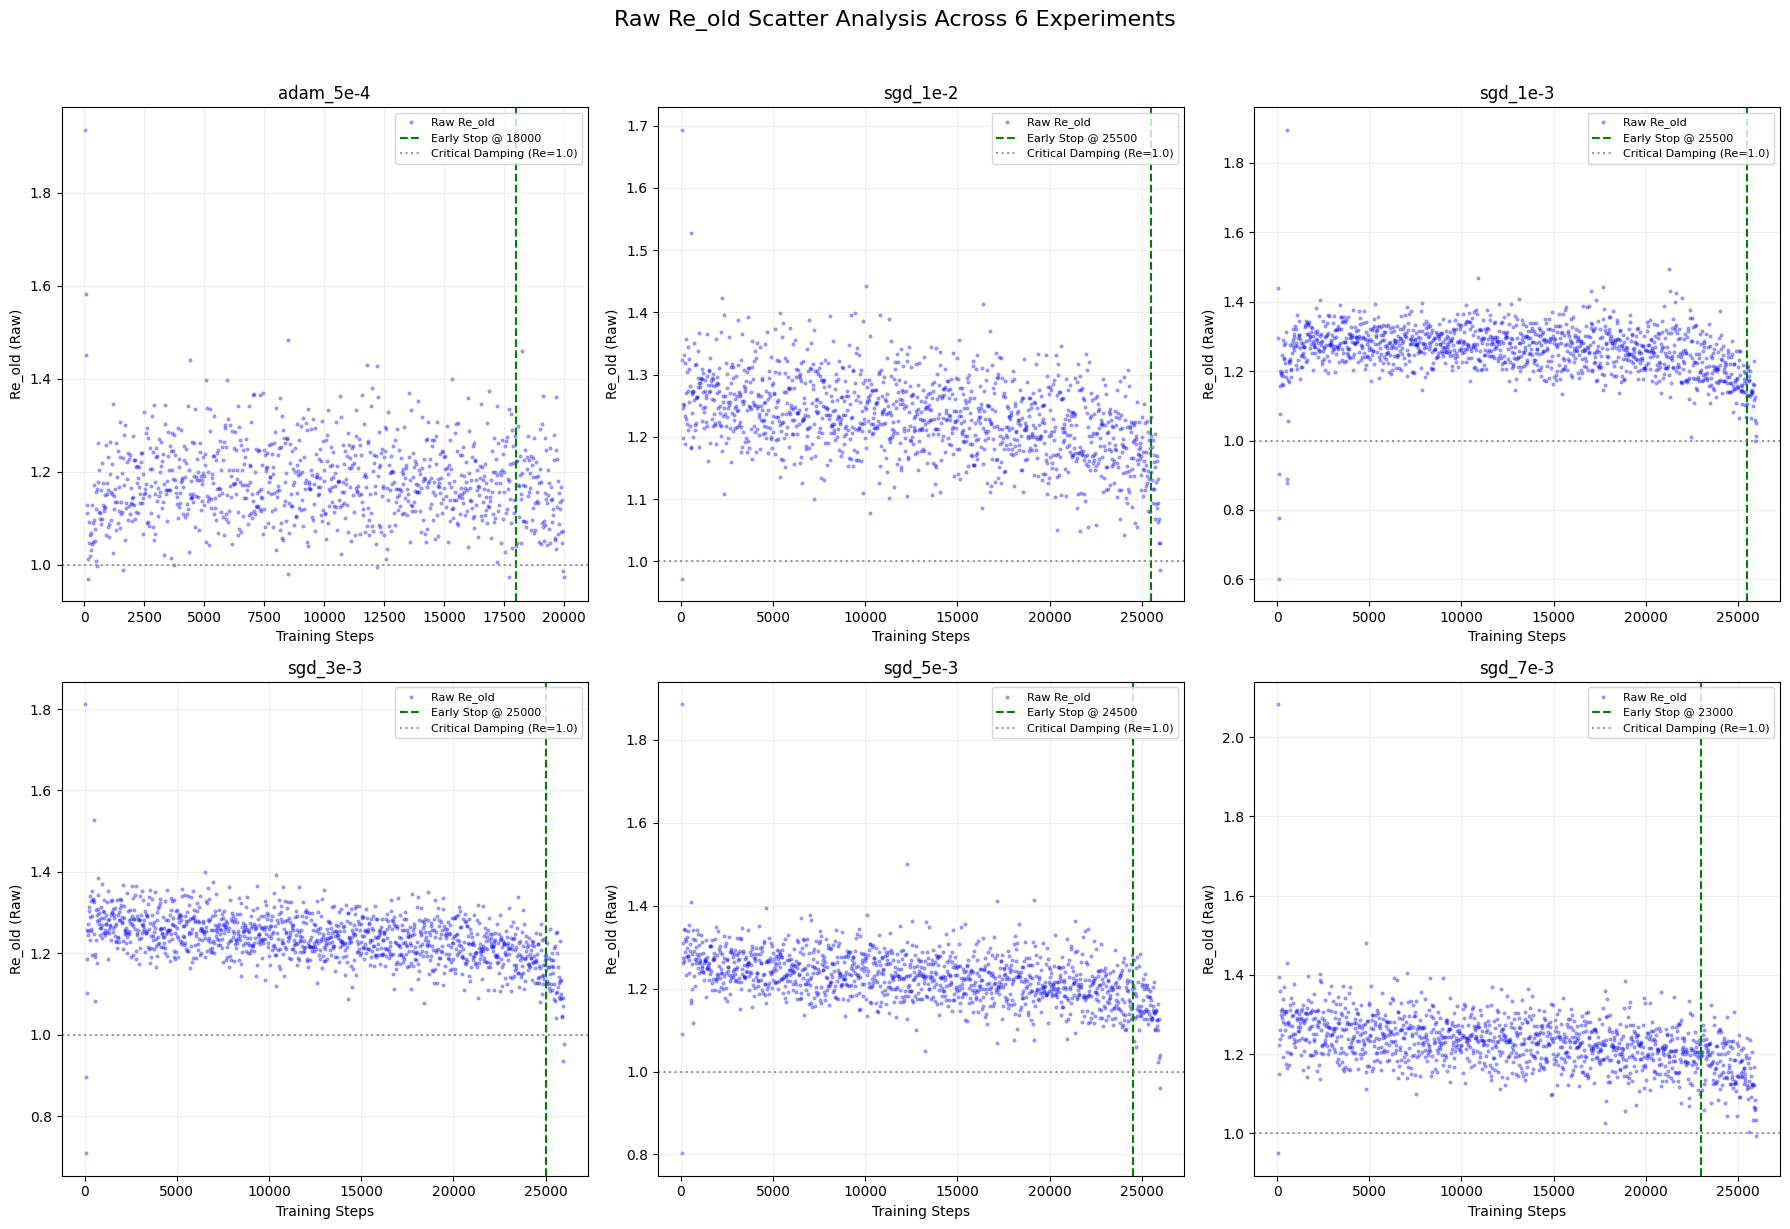

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# 1. Locate all experiment data files
file_pattern = "re_data_*.npz"
files = sorted(glob.glob(file_pattern))
n_exps = len(files)

print(f"Found {n_exps} experiment data files.")

if n_exps == 0:
    print("⚠️ No 're_data_*.npz' files found. Please upload and unzip the 6 .npz files.")
else:
    # 2. Create figure grid
    n_cols = 3
    n_rows = (n_exps + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
    axes = axes.flatten()

    for i, file_path in enumerate(files):
        exp_name = os.path.basename(file_path).replace("re_data_", "").replace(".npz", "")
        data = np.load(file_path, allow_pickle=True)

        steps = data['steps']
        re_old_raw = data['Re_old_raw']

        val_loss = data['val_loss']
        val_steps = data['val_steps']

        # Align data (handle the length mismatch from the first two unsampled steps)
        if len(steps) != len(re_old_raw):
            steps = steps[-len(re_old_raw):]

        # Find early stopping point
        min_loss_idx = np.argmin(val_loss)
        early_stop_step = val_steps[min_loss_idx]

        ax = axes[i]
        ax.scatter(steps, re_old_raw, s=4, alpha=0.3, color='blue', label='Raw Re_old')

        ax.axvline(x=early_stop_step, color='green', linestyle='--', linewidth=1.5,
                   label=f'Early Stop @ {early_stop_step}')

        ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.5, alpha=0.8, label='Critical Damping (Re=1.0)')

        ax.set_title(f"{exp_name}", fontsize=12)
        ax.set_xlabel("Training Steps")
        ax.set_ylabel("Re_old (Raw)")
        ax.grid(True, alpha=0.2)
        ax.legend(loc='upper right', fontsize=8)

    for j in range(n_exps, len(axes)):
        axes[j].axis('off')

    plt.suptitle("Raw Re_old Scatter Analysis Across 6 Experiments", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

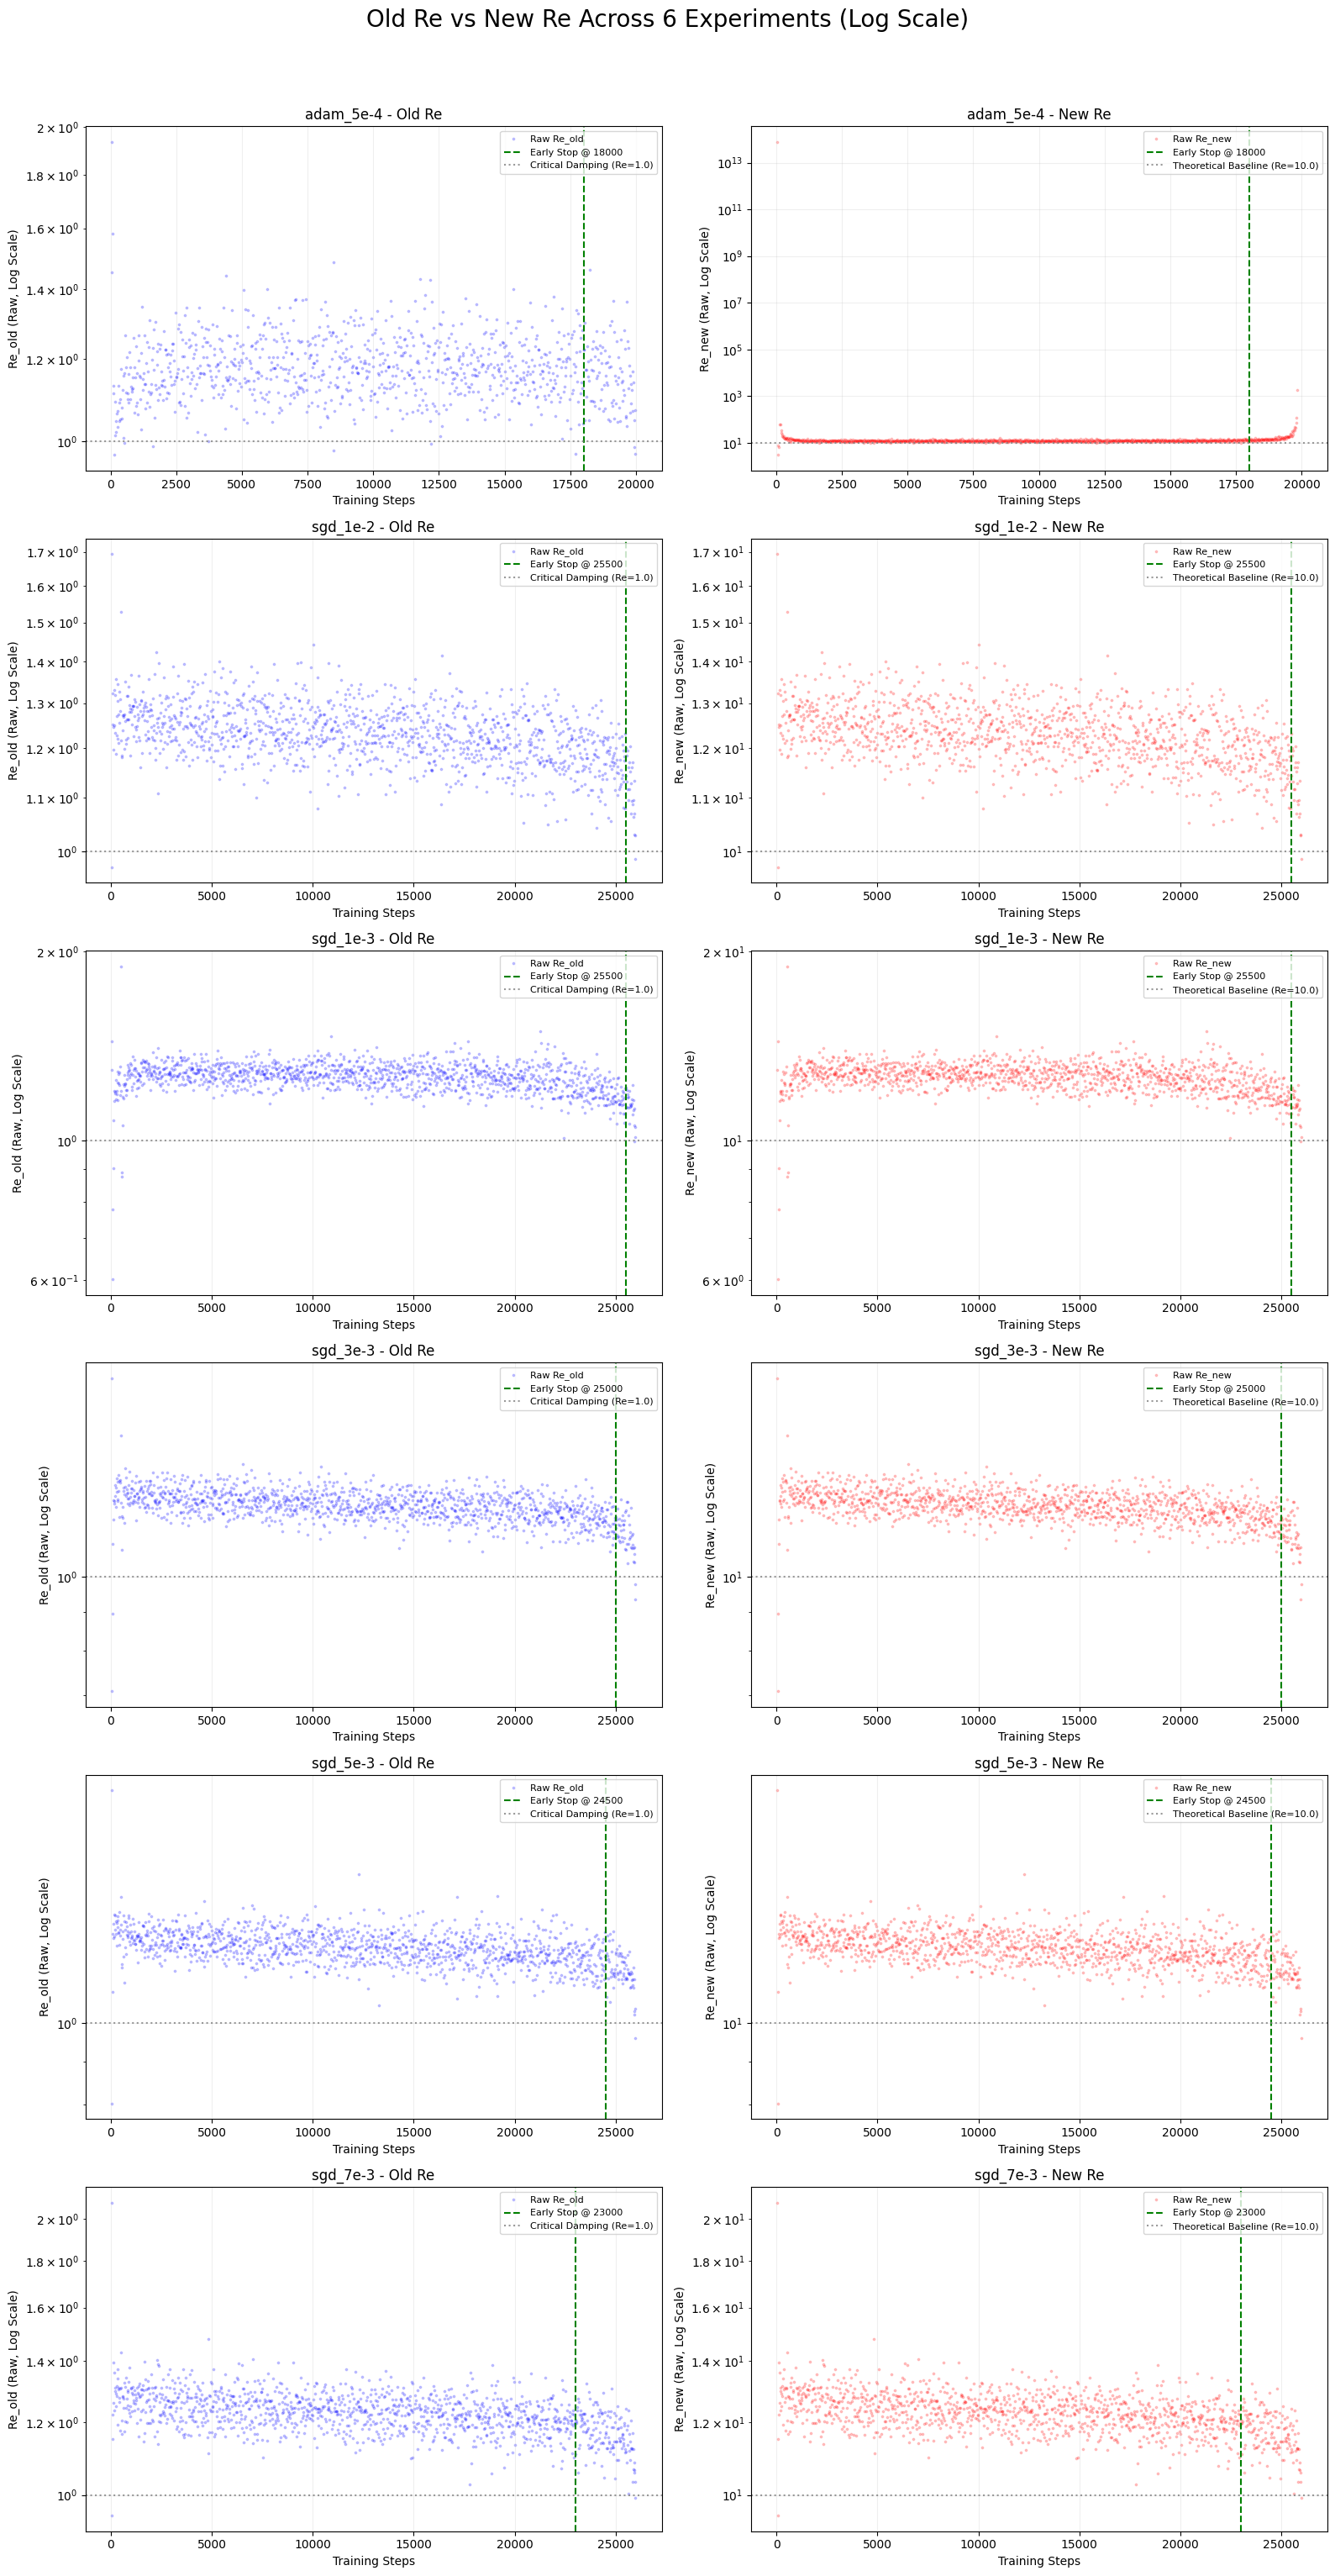

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# 1. 查找所有实验数据文件
file_pattern = "re_data_*.npz"
files = sorted(glob.glob(file_pattern))
n_exps = len(files)

if n_exps == 0:
    print("⚠️ No 're_data_*.npz' files found. Please unzip the data first.")
else:
    # 2. 创建 6行 x 2列 的子图网格
    n_rows = n_exps
    n_cols = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))

    for i, file_path in enumerate(files):
        exp_name = os.path.basename(file_path).replace("re_data_", "").replace(".npz", "")
        data = np.load(file_path, allow_pickle=True)

        steps = data['steps']
        re_old_raw = data['Re_old_raw']
        re_new_raw = data['Re_new_raw']

        val_loss = data['val_loss']
        val_steps = data['val_steps']

        # 对齐数据长度 (解决前两步没有Re值的问题)
        if len(steps) != len(re_old_raw):
            steps = steps[-len(re_old_raw):]

        # 找到早停点
        min_loss_idx = np.argmin(val_loss)
        early_stop_step = val_steps[min_loss_idx]

        # --- 绘制旧 Re (左列) ---
        ax_old = axes[i, 0]
        ax_old.scatter(steps, re_old_raw, s=3, alpha=0.2, color='blue', label='Raw Re_old')
        ax_old.axvline(x=early_stop_step, color='green', linestyle='--', linewidth=1.5, label=f'Early Stop @ {early_stop_step}')
        ax_old.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.5, alpha=0.8, label='Critical Damping (Re=1.0)')

        ax_old.set_yscale('log') # 统一对数坐标
        ax_old.set_title(f"{exp_name} - Old Re", fontsize=12)
        ax_old.set_xlabel("Training Steps")
        ax_old.set_ylabel("Re_old (Raw, Log Scale)")
        ax_old.grid(True, alpha=0.2)
        ax_old.legend(loc='upper right', fontsize=8)

        # --- 绘制新 Re (右列) ---
        ax_new = axes[i, 1]
        ax_new.scatter(steps, re_new_raw, s=3, alpha=0.2, color='red', label='Raw Re_new')
        ax_new.axvline(x=early_stop_step, color='green', linestyle='--', linewidth=1.5, label=f'Early Stop @ {early_stop_step}')
        # 对于 SGD, 理论上 new Re 稳定在 1/(1-beta) = 10.0
        ax_new.axhline(y=10.0, color='gray', linestyle=':', linewidth=1.5, alpha=0.8, label='Theoretical Baseline (Re=10.0)')

        ax_new.set_yscale('log') # 统一对数坐标
        ax_new.set_title(f"{exp_name} - New Re", fontsize=12)
        ax_new.set_xlabel("Training Steps")
        ax_new.set_ylabel("Re_new (Raw, Log Scale)")
        ax_new.grid(True, alpha=0.2)
        ax_new.legend(loc='upper right', fontsize=8)

    # 调整整体布局
    plt.suptitle("Old Re vs New Re Across 6 Experiments (Log Scale)", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()